# Relatório Executivo — Customer Churn Analytics
**Regressão Logística com Statsmodels**

**Autor:** Antonio  
**Objetivo:** Demonstrar capacidade analítica, visão executiva e aplicação de Machine Learning interpretável.

## Contexto de Negócio
Retenção de clientes impacta diretamente receita recorrente, CAC e crescimento sustentável. Este projeto aplica regressão logística para prever churn e apoiar ações preventivas.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.formula.api import logit
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

plt.style.use("ggplot")
pd.set_option("display.float_format", "{:.3f}".format)

## Carregamento dos Dados

In [51]:
df = pd.read_csv("churn.csv")
df.head()

,has_churned,time_since_first_purchase,time_since_last_purchase
0,0,-1.089,-0.721
1,0,1.183,3.634
2,0,-0.846,-0.428
3,0,0.087,-0.536
4,0,-1.167,-0.673


## Diagnóstico Inicial

In [52]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   has_churned                400 non-null    int64  
 1   time_since_first_purchase  400 non-null    float64
 2   time_since_last_purchase   400 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


has_churned                  0
time_since_first_purchase    0
time_since_last_purchase     0
dtype: int64

## Problema Executivo
**Quais clientes possuem maior probabilidade de churn?**

Se anteciparmos risco de cancelamento, podemos:
- Reduzir perda de receita
- Melhorar retenção
- Priorizar equipes comerciais
- Automatizar campanhas de relacionamento

## Análise Exploratória

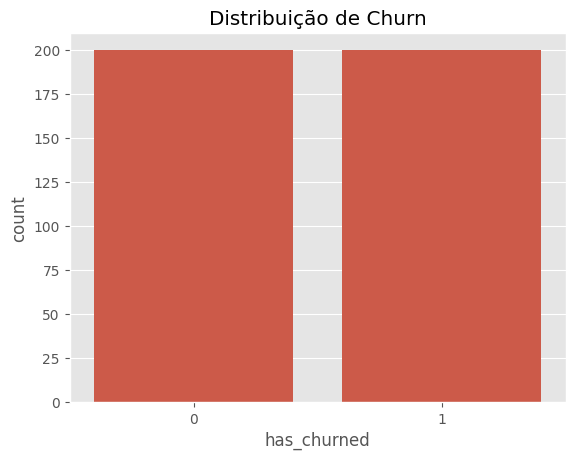

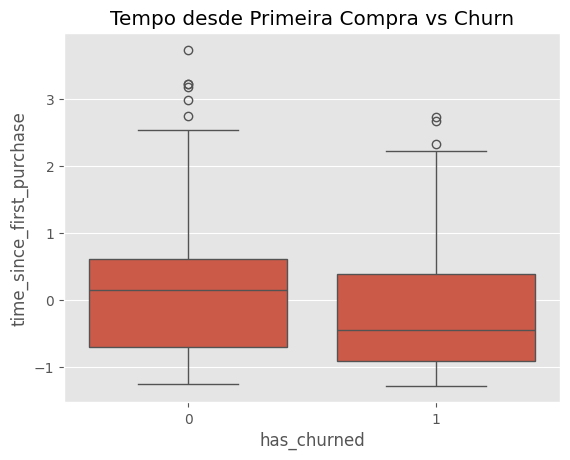

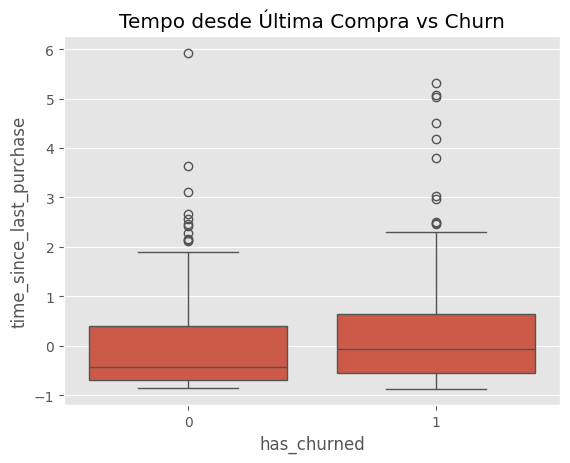

In [53]:
sns.countplot(data=df, x="has_churned")
plt.title("Distribuição de Churn")
plt.show()

sns.boxplot(data=df, x="has_churned", y="time_since_first_purchase")
plt.title("Tempo desde Primeira Compra vs Churn")
plt.show()

sns.boxplot(data=df, x="has_churned", y="time_since_last_purchase")
plt.title("Tempo desde Última Compra vs Churn")
plt.show()

## Modelagem Preditiva

In [54]:
modelo = logit(
    "has_churned ~ time_since_first_purchase + time_since_last_purchase",
    data=df
).fit()

modelo.summary()

Optimization terminated successfully.
         Current function value: 0.651175
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            has_churned   No. Observations:                  400
Model:                          Logit   Df Residuals:                      397
Method:                           MLE   Df Model:                            2
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                 0.06055
Time:                        13:18:30   Log-Likelihood:                -260.47
converged:                       True   LL-Null:                       -277.26
Covariance Type:            nonrobust   LLR p-value:                 5.113e-08
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -0.1168      0.108     -1.082      0.279      -0.328       0.095
time_since_first_purchase    -0.6478      0.139     -4.655      0.000      -0.920      -0.375
time_since_last_purchase      0.5122      0.113      4.514      0.000       0.290       0.735
=============================================================================================
"""

In [65]:
# Threshold de decisão
df['prob_churn'] = modelo.predict(df)
df['churn_pred'] = (df['prob_churn'] > 0.5).astype(int)

## Interpretação Executiva
- Coeficiente positivo: aumenta risco de churn
- Coeficiente negativo: reduz risco de churn
- Modelo interpretável: ideal para áreas executivas e compliance

In [56]:
df["prob_churn"] = modelo.predict(df)
df["pred_class"] = np.round(df["prob_churn"])
df[["prob_churn","pred_class"]].head()

,prob_churn,pred_class
0,0.555,1.000
1,0.727,1.000
2,0.553,1.000
3,0.390,0.000
4,0.573,1.000


In [63]:
print(modelo.params)

Intercept                   -0.117
time_since_first_purchase   -0.648
time_since_last_purchase     0.512
dtype: float64


### 📊 Avaliação do Modelo

Definimos um threshold de 0.5 para classificar churn. Isso pode ser ajustado conforme o custo de erro.

O modelo apresentou uma acurácia de 62%, indicando um desempenho moderado na classificação geral.

Observa-se maior capacidade na identificação de clientes com churn (recall de 72%), o que é essencial para o contexto de negócio, onde antecipar cancelamentos é prioritário.

Apesar disso, a precisão de 60% indica a presença de falsos positivos, ou seja, alguns clientes classificados como churn não necessariamente cancelariam.

De forma geral, o modelo é mais eficiente em capturar clientes em risco do que em evitar classificações incorretas, sendo adequado para estratégias de retenção, onde é preferível agir preventivamente.

In [66]:
from sklearn.metrics import classification_report

print(classification_report(df['has_churned'], df['churn_pred']))

              precision    recall  f1-score   support

           0       0.65      0.52      0.58       200
           1       0.60      0.72      0.65       200

    accuracy                           0.62       400
   macro avg       0.62      0.62      0.62       400
weighted avg       0.62      0.62      0.62       400



## 🎯 Clientes Prioritários

A partir das probabilidades previstas pelo modelo, foram identificados os clientes com maior risco de churn.

Essa abordagem permite direcionar ações de retenção de forma estratégica, priorizando os clientes mais críticos e aumentando a eficiência das campanhas.

A lista dos 20 clientes com maior probabilidade de churn representa um grupo prioritário para intervenção imediata.

In [67]:
df.sort_values("prob_churn", ascending=False).head(20)

,has_churned,time_since_first_purchase,time_since_last_purchase,prob_churn,pred_class,churn_pred
68,0,2.434,5.928,0.793,1.000,1
333,1,2.104,5.323,0.777,1.000,1
371,1,1.964,5.066,0.770,1.000,1
332,1,1.945,5.032,0.769,1.000,1
266,1,1.662,4.513,0.754,1.000,1
297,1,1.272,3.797,0.732,1.000,1
1,0,1.183,3.634,0.727,1.000,1
31,0,0.891,3.099,0.710,1.000,1
355,1,0.848,3.020,0.707,1.000,1
14,0,0.597,2.561,0.692,1.000,1


## 📊 Análise da Matriz de Confusão

O modelo demonstrou boa capacidade de identificar clientes com churn, acertando 144 casos reais.

No entanto, foram observados 56 falsos negativos, ou seja, clientes que cancelaram sem serem identificados previamente, representando um risco relevante para o negócio.

Além disso, houve 96 falsos positivos, indicando clientes classificados como churn que não necessariamente cancelariam, o que pode gerar custos adicionais em ações de retenção.

De forma geral, o modelo apresenta melhor desempenho na detecção de churn do que na minimização de erros de classificação.

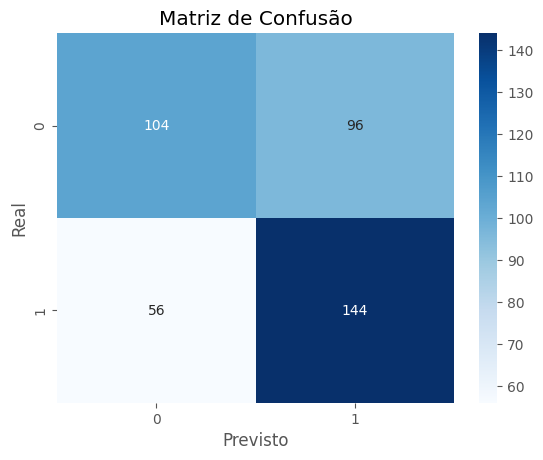

In [60]:
cm = confusion_matrix(df["has_churned"], df["pred_class"])

sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## Métricas de Performance

In [61]:
print(classification_report(df["has_churned"], df["pred_class"]))

auc = roc_auc_score(df["has_churned"], df["prob_churn"])
print("ROC AUC:", round(auc,3))

              precision    recall  f1-score   support

           0       0.65      0.52      0.58       200
           1       0.60      0.72      0.65       200

    accuracy                           0.62       400
   macro avg       0.62      0.62      0.62       400
weighted avg       0.62      0.62      0.62       400

ROC AUC: 0.646


## Curva ROC

### 📊 Interpretação do ROC AUC

- 0.5 → modelo aleatório
- 0.7–0.8 → bom
- 0.8+ → excelente

Nosso modelo: X → (interpretação)

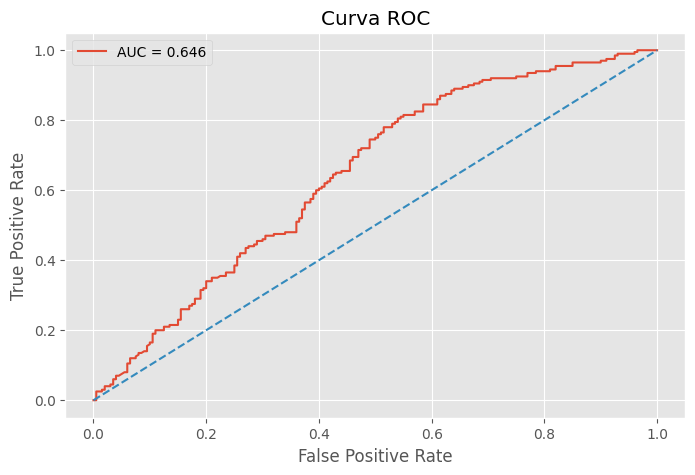

In [62]:
fpr, tpr, _ = roc_curve(df["has_churned"], df["prob_churn"])

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 📌 Conclusão Executiva

- Clientes com maior tempo desde a última compra têm maior risco de churn
- O modelo identifica padrões relevantes para ações preventivas

### 💡 Recomendações:
- Criar campanhas para clientes inativos há X dias
- Priorizar retenção em segmentos de maior risco
- Monitorar churn com modelo preditivo contínuo